In [1]:
!pip install -q datasets pandas

In [2]:
from datasets import load_dataset
import pandas as pd
from pathlib import Path

In [3]:
#Creating base folders
base = Path("/content/medagent_data/raw")
base.mkdir(parents=True, exist_ok=True)

print("Created:", base)

Created: /content/medagent_data/raw


In [4]:
#Loading PubMed dataset
pubmed_ds = load_dataset("pietrolesci/pubmed-200k-rct")

print("PubMed loaded")
print(pubmed_ds)
print(pubmed_ds["train"][0])
print(pubmed_ds["train"].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-12ed98a863dcf4(…):   0%|          | 0.00/204M [00:00<?, ?B/s]

data/validation-00000-of-00001-6f6e21b16(…):   0%|          | 0.00/2.68M [00:00<?, ?B/s]

data/test-00000-of-00001-1d0cf0c8a9ba23d(…):   0%|          | 0.00/2.70M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2211861 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/28932 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29493 [00:00<?, ? examples/s]

PubMed loaded
DatasetDict({
    train: Dataset({
        features: ['labels', 'text', 'uid'],
        num_rows: 2211861
    })
    validation: Dataset({
        features: ['labels', 'text', 'uid'],
        num_rows: 28932
    })
    test: Dataset({
        features: ['labels', 'text', 'uid'],
        num_rows: 29493
    })
})
{'labels': 0, 'text': 'The emergence of HIV as a chronic condition means that people living with HIV are required to take more responsibility for the self-management of their condition , including making physical , emotional and social adjustments .\n', 'uid': 0}
['labels', 'text', 'uid']


In [5]:
#Load MedQuAD dataset
try:
    medquad_ds = load_dataset("lavita/MedQuAD")
except:
    medquad_ds = load_dataset("keivalya/MedQuad-MedicalQnADataset")

print("MedQuAD loaded")
print(medquad_ds)
print(medquad_ds["train"][0])
print(medquad_ds["train"].column_names)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-e36383d177026d(…):   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/47441 [00:00<?, ? examples/s]

MedQuAD loaded
DatasetDict({
    train: Dataset({
        features: ['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer'],
        num_rows: 47441
    })
})
{'document_id': '0000559', 'document_source': 'GHR', 'document_url': 'https://ghr.nlm.nih.gov/condition/keratoderma-with-woolly-hair', 'category': None, 'umls_cui': 'C0343073', 'umls_semantic_types': 'T047', 'umls_semantic_group': 'Disorders', 'synonyms': 'KWWH', 'question_id': '0000559-1', 'question_focus': 'keratoderma with woolly hair', 'question_type': 'information', 'question': 'What is (are) keratoderma with woolly hair ?', 'answer': 'Keratoderma with woolly hair is a group of related conditions that affect the skin and hair and in many cases increase the risk of potentially life-threatening heart problems. People with these conditions have hair that is unusually coarse, dry, f

In [71]:
#Clone Synthea
%cd /content/medagent_data/raw
!git clone https://github.com/synthetichealth/synthea.git

/content/medagent_data/raw
fatal: destination path 'synthea' already exists and is not an empty directory.


In [7]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [8]:
%cd /content/medagent_data/raw/synthea
!chmod +x gradlew
!./gradlew build -x test --no-daemon

/content/medagent_data/raw/synthea
............10%.............20%.............30%.............40%.............50%.............60%.............70%.............80%.............90%.............100%

Welcome to Gradle 9.2.1!

Here are the highlights of this release:
 - Windows ARM support
 - Improved publishing APIs
 - Better guidance for dependency verification failures

For more details see https://docs.gradle.org/9.2.1/release-notes.html

To honour the JVM settings for this build a single-use Daemon process will be forked. For more on this, please refer to https://docs.gradle.org/9.2.1/userguide/gradle_daemon.html#sec:disabling_the_daemon in the Gradle documentation.


> Starting Daemon> IDLEDaemon will be stopped at the end of the build 

> IDLE<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-----

In [9]:
#Generate patient data
%cd /content/medagent_data/raw/synthea
!chmod +x run_synthea
!./run_synthea -p 50

/content/medagent_data/raw/synthea
Starting a Gradle Daemon (subsequent builds will be faster)


> Starting Daemon> IDLE<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING s]<-------------> 0% INITIALIZING [1s]> Evaluating settings<-------------> 0% INITIALIZING [2s]> IDLE<-------------> 0% CONFIGURING [2s]> Loading projects> root project<-------------> 0% CONFIGURING [3s]> root project > Resolve dependencies of detachedConfiguration1> root project<-------------> 0% CONFIGURING [4s]> root project > Resolve dependencies of classpath> root project > Resolve files of configuration 'classpath' > Resolve files of > root project > Resolve files of configuration 'classpath'> root project<-------------> 0% CONFIG

In [10]:
%cd /content/medagent_data/raw/synthea

!./run_synthea -p 50 Massachusetts --exporter.csv.export=true

/content/medagent_data/raw/synthea


<-------------> 0% CONFIGURING s]> root project > Resolve dependencies of detachedConfiguration1<-------------> 0% CONFIGURING s]> root project > Resolve files of configuration 'classpath'<-------------> 0% CONFIGURING s]> root project<=============> 100% CONFIGURING s]> IDLE<==-----------> 20% EXECUTING s]> :compileJava > Resolve dependencies of :compileClasspath<==-----------> 20% EXECUTING s]<==-----------> 20% EXECUTING s]> :compileJava > Resolve files of configuration ':compileClasspath'<==========---> 80% EXECUTING s]> :run > Resolve dependencies of :runtimeClasspath<==========---> 80% EXECUTING s]> :run<==========---> 80% EXECUTING s]<==========---> 80% EXECUTING [1s]<==========---> 80% EXECUTING [2s]<==========---> 80% EXECUTING [3s]<==========---> 80% EXECUTING [4s]
> Task :run
SLF4J: No SLF4J providers were found.
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#noProviders for furthe

In [11]:
from pathlib import Path

csv_path = Path("/content/medagent_data/raw/synthea/output/csv")

print("CSV files:")
print(list(csv_path.glob("*.csv")))

CSV files:
[PosixPath('/content/medagent_data/raw/synthea/output/csv/imaging_studies.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/supplies.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/claims_transactions.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/payers.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/providers.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/immunizations.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/conditions.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/allergies.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/patients.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/devices.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/encounters.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/organizations.csv'), PosixPath('/content/medagent_data/raw/synthea/output/csv/careplans.csv'), PosixPa

In [12]:
from pathlib import Path
import os

synthea_dir = Path("/content/medagent_data/raw/synthea")
print("Synthea exists:", synthea_dir.exists())

for root, dirs, files in os.walk(synthea_dir):
    level = root.replace(str(synthea_dir), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:10]:
        print(f"{indent}  {f}")
    if level >= 2:
        continue

Synthea exists: True
synthea/
  build.gradle
  gradlew.bat
  gradlew
  .lift.toml
  run_flexporter
  generate_samples.sh
  run_synthea
  NOTICE
  run_synthea.bat
  .gitignore
  output/
    metadata/
      2026_04_12T20_07_28Z_50_Massachusetts_751ca9cb_520e_440f_bf1d_1df3bc3ae148.json
      2026_04_12T20_08_46Z_50_Massachusetts_2db8c953_66e0_4bf9_ad5e_e4962dd49ba8.json
    fhir/
      Yong583_Lesli455_Smith67_139699eb-dc14-6598-26a1-b29d074e7c43.json
      Norine97_Kub800_6c80a28a-48a8-a33a-001e-9ec62a80f852.json
      Jose871_Mertz280_3764fe87-c1ea-3fae-0084-a7cd4be355c8.json
      Jeffie441_Bernhard322_afe12b21-b38e-c7bd-2b2e-ca2dff451aa4.json
      Sabine292_Schaefer657_b8720eea-9870-59d7-8e03-e6f6d58e0a5a.json
      Quintin944_Ullrich385_1d1938b7-e3e3-b088-b3b4-cfd68772ca84.json
      Chas63_Larkin917_84febb79-a49e-4199-ade0-ce49e5a23fab.json
      Winfred745_Larson43_aec82f96-611c-3968-033e-6b020d90dd49.json
      Damion480_Glover433_f3801379-f673-8516-affd-d636d3297c20.json
      

In [13]:
#Load Synthea data
patients = pd.read_csv(csv_path / "patients.csv")
conditions = pd.read_csv(csv_path / "conditions.csv")
medications = pd.read_csv(csv_path / "medications.csv")
observations = pd.read_csv(csv_path / "observations.csv")

print("Patients:", patients.shape)
print("Conditions:", conditions.shape)
print("Medications:", medications.shape)
print("Observations:", observations.shape)

Patients: (52, 28)
Conditions: (1384, 7)
Medications: (864, 13)
Observations: (19826, 9)


In [14]:
display(patients.head())
display(conditions.head())
display(medications.head())
display(observations.head())

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,b6a0779f-41f7-0291-edd3-f570686fdf66,1960-10-09,NaN,999-76-5653,S99914046,X13778763X,Mrs.,Eleanor470,NaN,Block661,...,North Adams,Massachusetts,Berkshire County,25003.0,1247,42.694882,-73.070431,757255.87,122100.39,35527
1,030d3376-59f8-2111-3587-c6424f6c0a11,1959-10-02,NaN,999-87-1411,S99967412,X7084837X,Ms.,Verena947,Louetta798,Ziemann98,...,Nantucket,Massachusetts,Nantucket County,25019.0,2554,41.276799,-70.121744,976125.67,130439.86,104864
2,590865fb-cfbb-76b0-1e6a-9ae7970c09b1,2013-01-10,NaN,999-61-5585,NaN,NaN,NaN,Angel97,Neal874,Cartwright189,...,North Attleborough,Massachusetts,Bristol County,NaN,0,41.947883,-71.347437,2395.54,33873.65,14491
3,79f24e10-f3a3-09cf-bd6c-de443a4e0453,2018-06-03,NaN,999-11-3998,NaN,NaN,NaN,Kendrick479,Edmond919,Schulist381,...,Raynham Center,Massachusetts,Bristol County,25005.0,2768,41.912411,-71.027505,24151.16,12271.39,51130
4,5db7ff0e-a844-c37d-3252-1aefd90d79ae,1978-12-02,NaN,999-88-7139,S99982896,X23513613X,Mr.,Joshua658,Phillip440,Tremblay80,...,Brockton,Massachusetts,Plymouth County,25023.0,2302,42.070261,-71.025331,93515.25,9443.39,28276


,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,1978-12-03,NaN,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-d97c-9487f612a5e6,http://snomed.info/sct,224295006,Only received primary school education (finding)
1,1988-12-18,NaN,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-ad8b-2ad7aa071e6f,http://snomed.info/sct,714628002,Prediabetes (finding)
2,1988-12-18,NaN,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-ad8b-2ad7aa071e6f,http://snomed.info/sct,271737000,Anemia (disorder)
3,1988-12-18,NaN,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-ad8b-2ad7aa071e6f,http://snomed.info/sct,162864005,Body mass index 30+ - obesity (finding)
4,1996-09-26,NaN,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-2330-efd928517406,http://snomed.info/sct,267020005,History of tubal ligation (situation)


,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,2019-04-04T05:39:40Z,2019-04-13T05:39:40Z,b6a0779f-41f7-0291-edd3-f570686fdf66,0133f751-9229-3cfd-815f-b6d4979bdd6a,b6a0779f-41f7-0291-dbb9-7bef57c2070c,313782,Acetaminophen 325 MG Oral Tablet,45.86,0.00,1,45.86,10509002.0,Acute bronchitis (disorder)
1,2018-12-08T02:47:52Z,2018-12-08T02:47:52Z,030d3376-59f8-2111-3587-c6424f6c0a11,e03e23c9-4df1-3eb6-a62d-f70f02301496,030d3376-59f8-2111-3e6f-a5bce83de004,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,0.00,1,129.94,66383009.0,Gingivitis (disorder)
2,2021-12-25T02:12:16Z,2021-12-25T02:12:16Z,030d3376-59f8-2111-3587-c6424f6c0a11,e03e23c9-4df1-3eb6-a62d-f70f02301496,030d3376-59f8-2111-a083-7fac16f2c247,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,0.00,1,129.94,103697008.0,Patient referral for dental care (procedure)
3,2023-01-18T23:49:39Z,2023-02-10T23:49:39Z,030d3376-59f8-2111-3587-c6424f6c0a11,e03e23c9-4df1-3eb6-a62d-f70f02301496,030d3376-59f8-2111-4a57-7708c3222a01,310965,Ibuprofen 200 MG Oral Tablet,42.24,0.00,1,42.24,NaN,NaN
4,2025-01-11T02:04:23Z,2025-01-11T02:04:23Z,030d3376-59f8-2111-3587-c6424f6c0a11,a735bf55-83e9-331a-899d-a82a60b9f60c,030d3376-59f8-2111-60a6-9a2aca5af4a0,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,103.95,1,129.94,66383009.0,Gingivitis (disorder)


,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2016-11-13T18:17:23Z,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-72af-27f1b5003a24,laboratory,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,6.3,%,numeric
1,2016-11-13T18:17:23Z,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-72af-27f1b5003a24,vital-signs,8302-2,Body Height,167.9,cm,numeric
2,2016-11-13T18:17:23Z,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-72af-27f1b5003a24,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,1.0,{score},numeric
3,2016-11-13T18:17:23Z,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-72af-27f1b5003a24,vital-signs,29463-7,Body Weight,79.2,kg,numeric
4,2016-11-13T18:17:23Z,b6a0779f-41f7-0291-edd3-f570686fdf66,b6a0779f-41f7-0291-72af-27f1b5003a24,vital-signs,39156-5,Body mass index (BMI) [Ratio],28.1,kg/m2,numeric


In [15]:
encounters = pd.read_csv(csv_path / "encounters.csv")

In [16]:
print("PATIENTS:", patients.columns.tolist())
print("CONDITIONS:", conditions.columns.tolist())
print("MEDICATIONS:", medications.columns.tolist())
print("OBSERVATIONS:", observations.columns.tolist())
print("ENCOUNTERS:", encounters.columns.tolist())

PATIENTS: ['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']
CONDITIONS: ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE', 'DESCRIPTION']
MEDICATIONS: ['START', 'STOP', 'PATIENT', 'PAYER', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'PAYER_COVERAGE', 'DISPENSES', 'TOTALCOST', 'REASONCODE', 'REASONDESCRIPTION']
OBSERVATIONS: ['DATE', 'PATIENT', 'ENCOUNTER', 'CATEGORY', 'CODE', 'DESCRIPTION', 'VALUE', 'UNITS', 'TYPE']
ENCOUNTERS: ['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']


In [17]:
def build_patient_report(patient_id, patients, conditions, medications, observations):
    p = patients[patients["Id"] == patient_id].iloc[0]

    patient_conditions = (
        conditions[conditions["PATIENT"] == patient_id]["DESCRIPTION"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    patient_meds = (
        medications[medications["PATIENT"] == patient_id]["DESCRIPTION"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    patient_obs = observations[observations["PATIENT"] == patient_id].copy()

    obs_lines = []
    if not patient_obs.empty:
        cols_needed = ["DESCRIPTION", "VALUE", "UNITS"]
        available_cols = [c for c in cols_needed if c in patient_obs.columns]
        patient_obs = patient_obs[available_cols].dropna(subset=["DESCRIPTION"])
        for _, row in patient_obs.head(15).iterrows():
            desc = str(row.get("DESCRIPTION", ""))
            val = str(row.get("VALUE", ""))
            unit = str(row.get("UNITS", ""))
            obs_lines.append(f"{desc}: {val} {unit}".strip())

    first_name = str(p.get("FIRST", ""))
    last_name = str(p.get("LAST", ""))
    gender = str(p.get("GENDER", ""))
    birthdate = str(p.get("BIRTHDATE", ""))

    report = f"""
Patient Name: {first_name} {last_name}
Gender: {gender}
Birthdate: {birthdate}

Known Conditions:
{', '.join(patient_conditions) if patient_conditions else 'None recorded'}

Medications:
{', '.join(patient_meds) if patient_meds else 'None recorded'}

Recent Observations:
{' ; '.join(obs_lines) if obs_lines else 'None recorded'}
""".strip()

    return report

In [18]:
sample_patient_id = patients.iloc[0]["Id"]
sample_report = build_patient_report(sample_patient_id, patients, conditions, medications, observations)

print(sample_report)

Patient Name: Eleanor470 Block661
Gender: F
Birthdate: 1960-10-09

Known Conditions:
Only received primary school education (finding), Prediabetes (finding), Anemia (disorder), Body mass index 30+ - obesity (finding), History of tubal ligation (situation), Medication review due (situation), Full-time employment (finding), Stress (finding), Unhealthy alcohol drinking behavior (finding), Part-time employment (finding), Limited social contact (finding), Victim of intimate partner abuse (finding), Gingivitis (disorder), Acute bronchitis (disorder), Unemployed (finding), Not in labor force (finding), Viral sinusitis (disorder)

Medications:
Acetaminophen 325 MG Oral Tablet

Recent Observations:
Hemoglobin A1c/Hemoglobin.total in Blood: 6.3 % ; Body Height: 167.9 cm ; Pain severity - 0-10 verbal numeric rating [Score] - Reported: 1.0 {score} ; Body Weight: 79.2 kg ; Body mass index (BMI) [Ratio]: 28.1 kg/m2 ; Diastolic Blood Pressure: 88.0 mm[Hg] ; Systolic Blood Pressure: 132.0 mm[Hg] ; Hea

In [19]:
reports = []

for patient_id in patients["Id"].head(50):
    try:
        report_text = build_patient_report(patient_id, patients, conditions, medications, observations)
        reports.append({
            "patient_id": patient_id,
            "report_text": report_text
        })
    except Exception as e:
        print("Skipping patient:", patient_id, "| Error:", e)

reports_df = pd.DataFrame(reports)

print("Generated reports:", reports_df.shape)
display(reports_df.head())

Generated reports: (50, 2)


,patient_id,report_text
0,b6a0779f-41f7-0291-edd3-f570686fdf66,Patient Name: Eleanor470 Block661\nGender: F\n...
1,030d3376-59f8-2111-3587-c6424f6c0a11,Patient Name: Verena947 Ziemann98\nGender: F\n...
2,590865fb-cfbb-76b0-1e6a-9ae7970c09b1,Patient Name: Angel97 Cartwright189\nGender: M...
3,79f24e10-f3a3-09cf-bd6c-de443a4e0453,Patient Name: Kendrick479 Schulist381\nGender:...
4,5db7ff0e-a844-c37d-3252-1aefd90d79ae,Patient Name: Joshua658 Tremblay80\nGender: M\...


In [20]:
simple_map = {
    "Hypertension": "high blood pressure",
    "Diabetes": "high blood sugar condition",
    "Obesity": "excess body weight",
    "Asthma": "a breathing condition",
    "Hyperlipidemia": "high fat levels in the blood"
}

def simplify_text(text):
    out = text
    for medical_term, simple_term in simple_map.items():
        out = out.replace(medical_term, simple_term)
    return out

reports_df["plain_explanation"] = reports_df["report_text"].apply(simplify_text)

display(reports_df[["report_text", "plain_explanation"]].head(2))

,report_text,plain_explanation
0,Patient Name: Eleanor470 Block661\nGender: F\n...,Patient Name: Eleanor470 Block661\nGender: F\n...
1,Patient Name: Verena947 Ziemann98\nGender: F\n...,Patient Name: Verena947 Ziemann98\nGender: F\n...


In [21]:
processed_dir = Path("/content/medagent_data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

reports_df.to_csv(processed_dir / "synthea_patient_reports.csv", index=False)

print("Saved:", processed_dir / "synthea_patient_reports.csv")

Saved: /content/medagent_data/processed/synthea_patient_reports.csv


In [22]:
print("Number of patients:", len(patients))
print("Number of generated reports:", len(reports_df))
print("Average report length:", reports_df["report_text"].str.len().mean())

Number of patients: 52
Number of generated reports: 50
Average report length: 1702.44


In [23]:
!pip install -q bioc transformers seqeval accelerate evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00


Loading bc5dr Dataset

In [26]:
import os
import requests

base_dir = "/content/bc5cdr_data"
os.makedirs(base_dir, exist_ok=True)

files = {
    "train.tsv": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-IOB/train.tsv",
    "validation.tsv": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-IOB/devel.tsv",
    "test.tsv": "https://raw.githubusercontent.com/cambridgeltl/MTL-Bioinformatics-2016/master/data/BC5CDR-IOB/test.tsv",
}

for filename, url in files.items():
    out_path = os.path.join(base_dir, filename)
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with open(out_path, "wb") as f:
        f.write(r.content)
    print(f"Downloaded {filename} -> {out_path}")

Downloaded train.tsv -> /content/bc5cdr_data/train.tsv
Downloaded validation.tsv -> /content/bc5cdr_data/validation.tsv
Downloaded test.tsv -> /content/bc5cdr_data/test.tsv


In [27]:
with open("/content/bc5cdr_data/train.tsv", "r", encoding="utf-8") as f:
    for i in range(20):
        print(repr(f.readline()))

'Selegiline\tB-Chemical\n'
'-\tO\n'
'induced\tO\n'
'postural\tB-Disease\n'
'hypotension\tI-Disease\n'
'in\tO\n'
'Parkinson\tB-Disease\n'
"'\tI-Disease\n"
's\tI-Disease\n'
'disease\tI-Disease\n'
':\tO\n'
'a\tO\n'
'longitudinal\tO\n'
'study\tO\n'
'on\tO\n'
'the\tO\n'
'effects\tO\n'
'of\tO\n'
'drug\tO\n'
'withdrawal\tO\n'


In [28]:
def read_conll_tsv(path):
    sentences = []
    tokens = []
    tags = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                if tokens:
                    sentences.append({"tokens": tokens, "tags": tags})
                    tokens, tags = [], []
                continue

            parts = line.split("\t")
            if len(parts) != 2:
                continue

            token, tag = parts
            tokens.append(token)
            tags.append(tag)

    if tokens:
        sentences.append({"tokens": tokens, "tags": tags})

    return sentences

train_data = read_conll_tsv("/content/bc5cdr_data/train.tsv")
val_data = read_conll_tsv("/content/bc5cdr_data/validation.tsv")
test_data = read_conll_tsv("/content/bc5cdr_data/test.tsv")

print("Train sentences:", len(train_data))
print("Validation sentences:", len(val_data))
print("Test sentences:", len(test_data))

print("\nSample:")
print(train_data[0])

Train sentences: 4560
Validation sentences: 4581
Test sentences: 4797

Sample:
{'tokens': ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.'], 'tags': ['B-Chemical', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


In [29]:
!pip install -q datasets transformers evaluate seqeval accelerate

In [30]:
from datasets import Dataset, DatasetDict

bc5cdr = DatasetDict({
    "train": Dataset.from_list(train_data),
    "validation": Dataset.from_list(val_data),
    "test": Dataset.from_list(test_data),
})

print(bc5cdr)
print(bc5cdr["train"][0])

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 4560
    })
    validation: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 4581
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 4797
    })
})
{'tokens': ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.'], 'tags': ['B-Chemical', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


In [31]:
all_labels = set()

for split in ["train", "validation", "test"]:
    for row in bc5cdr[split]:
        all_labels.update(row["tags"])

label_names = sorted(all_labels)
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

print("Labels:", label_names)

Labels: ['B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease', 'O']


In [32]:
def encode_tags(example):
    example["ner_tags"] = [label2id[tag] for tag in example["tags"]]
    return example

bc5cdr = bc5cdr.map(encode_tags)
print(bc5cdr["train"][0])

Map:   0%|          | 0/4560 [00:00<?, ? examples/s]

Map:   0%|          | 0/4581 [00:00<?, ? examples/s]

Map:   0%|          | 0/4797 [00:00<?, ? examples/s]

{'tokens': ['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.'], 'tags': ['B-Chemical', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'], 'ner_tags': [0, 4, 4, 1, 3, 4, 1, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]}


Loading Biobert

In [33]:
from transformers import AutoTokenizer

model_checkpoint = "dmis-lab/biobert-base-cased-v1.2"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [34]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=256
    )

    labels = []

    for i in range(len(examples["tokens"])):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        word_labels = examples["ner_tags"][i]

        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(word_labels[word_idx])
            else:
                current_label_id = word_labels[word_idx]
                current_label_name = id2label[current_label_id]

                if current_label_name.startswith("B-"):
                    inside_label = "I-" + current_label_name[2:]
                    label_ids.append(label2id.get(inside_label, current_label_id))
                else:
                    label_ids.append(current_label_id)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_bc5cdr = bc5cdr.map(tokenize_and_align_labels, batched=True)
print(tokenized_bc5cdr)

Map:   0%|          | 0/4560 [00:00<?, ? examples/s]

Map:   0%|          | 0/4581 [00:00<?, ? examples/s]

Map:   0%|          | 0/4797 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4560
    })
    validation: Dataset({
        features: ['tokens', 'tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4581
    })
    test: Dataset({
        features: ['tokens', 'tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4797
    })
})


In [36]:
import numpy as np
import evaluate

from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)

seqeval = evaluate.load("seqeval")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        pred_labels = []
        true_labs = []

        for p, l in zip(pred, lab):
            if l != -100:
                pred_labels.append(id2label[int(p)])
                true_labs.append(id2label[int(l)])

        true_predictions.append(pred_labels)
        true_labels.append(true_labs)

    results = seqeval.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="/content/biobert_bc5cdr_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_bc5cdr["train"],
    eval_dataset=tokenized_bc5cdr["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

Biobert model training

In [37]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.072346,0.110642,0.825429,0.887302,0.855248,0.965183
2,0.053018,0.118952,0.850338,0.891472,0.870419,0.968949
3,0.021333,0.139657,0.860491,0.895746,0.877765,0.968680


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1710, training_loss=0.0773663229761068, metrics={'train_runtime': 366.9558, 'train_samples_per_second': 37.28, 'train_steps_per_second': 4.66, 'total_flos': 492598574364000.0, 'train_loss': 0.0773663229761068, 'epoch': 3.0})

In [38]:
test_results = trainer.evaluate(tokenized_bc5cdr["test"])
print(test_results)

{'eval_loss': 0.1469981074333191, 'eval_precision': 0.8415736821854559, 'eval_recall': 0.8919359771638291, 'eval_f1': 0.8660232615689185, 'eval_accuracy': 0.9665250195126182, 'eval_runtime': 28.2251, 'eval_samples_per_second': 169.955, 'eval_steps_per_second': 21.258, 'epoch': 3.0}


In [39]:
save_dir = "/content/final_biobert_bc5cdr"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print("Saved model to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: /content/final_biobert_bc5cdr


In [40]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/biobert_bc5cdr_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Saved to:", save_path)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/biobert_bc5cdr_model


In [41]:
from transformers import AutoModelForTokenClassification, AutoTokenizer

model = AutoModelForTokenClassification.from_pretrained(save_path)
tokenizer = AutoTokenizer.from_pretrained(save_path)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [42]:
bc5cdr.save_to_disk("/content/drive/MyDrive/bc5cdr_dataset")
tokenized_bc5cdr.save_to_disk("/content/drive/MyDrive/tokenized_bc5cdr")

Saving the dataset (0/1 shards):   0%|          | 0/4560 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4581 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4797 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4560 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4581 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4797 [00:00<?, ? examples/s]

In [43]:
from datasets import load_from_disk

bc5cdr = load_from_disk("/content/drive/MyDrive/bc5cdr_dataset")
tokenized_bc5cdr = load_from_disk("/content/drive/MyDrive/tokenized_bc5cdr")

In [44]:
import os

project_dir = "/content/drive/MyDrive/medical_ner_project"
os.makedirs(project_dir, exist_ok=True)

raw_dir = os.path.join(project_dir, "raw_data")
processed_dir = os.path.join(project_dir, "processed_data")
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

print(project_dir)

/content/drive/MyDrive/medical_ner_project


In [45]:
import shutil
import glob
import os

synthea_source_dir = "/content/synthea/output/csv"   # change if your folder is different
synthea_target_dir = os.path.join(raw_dir, "synthea_csv")
os.makedirs(synthea_target_dir, exist_ok=True)

for file in glob.glob(os.path.join(synthea_source_dir, "*.csv")):
    shutil.copy(file, synthea_target_dir)

print("Saved Synthea CSVs to:", synthea_target_dir)
print(os.listdir(synthea_target_dir))

Saved Synthea CSVs to: /content/drive/MyDrive/medical_ner_project/raw_data/synthea_csv
[]


In [51]:
pubmed_ds.save_to_disk(os.path.join(project_dir, "pubmed_ds"))
medquad_ds.save_to_disk(os.path.join(project_dir, "medquad_ds"))

print("Saved pubmed_ds and medquad_ds")

Saving the dataset (0/1 shards):   0%|          | 0/2211861 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/28932 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/29493 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/47441 [00:00<?, ? examples/s]

Saved pubmed_ds and medquad_ds


In [52]:
medications.to_csv(os.path.join(project_dir, "medications.csv"), index=False)
print("Saved medications.csv")

Saved medications.csv


In [53]:
from datasets import load_from_disk

pubmed_ds = load_from_disk(os.path.join(project_dir, "pubmed_ds"))
medquad_ds = load_from_disk(os.path.join(project_dir, "medquad_ds"))

In [54]:
print(type(pubmed_ds))
print(type(medquad_ds))
print(type(medications))

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.dataset_dict.DatasetDict'>
<class 'pandas.core.frame.DataFrame'>


Evaluation Metrics

In [55]:
test_results = trainer.evaluate(tokenized_bc5cdr["test"])
print(test_results)

{'eval_loss': 0.1469981074333191, 'eval_precision': 0.8415736821854559, 'eval_recall': 0.8919359771638291, 'eval_f1': 0.8660232615689185, 'eval_accuracy': 0.9665250195126182, 'eval_runtime': 32.9553, 'eval_samples_per_second': 145.561, 'eval_steps_per_second': 18.206, 'epoch': 3.0}


In [56]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "Accuracy"],
    "Value": [
        test_results["eval_precision"],
        test_results["eval_recall"],
        test_results["eval_f1"],
        test_results["eval_accuracy"]
    ]
})

print(metrics_df)
metrics_df.to_csv("/content/test_metrics.csv", index=False)

      Metric     Value
0  Precision  0.841574
1     Recall  0.891936
2   F1-score  0.866023
3   Accuracy  0.966525


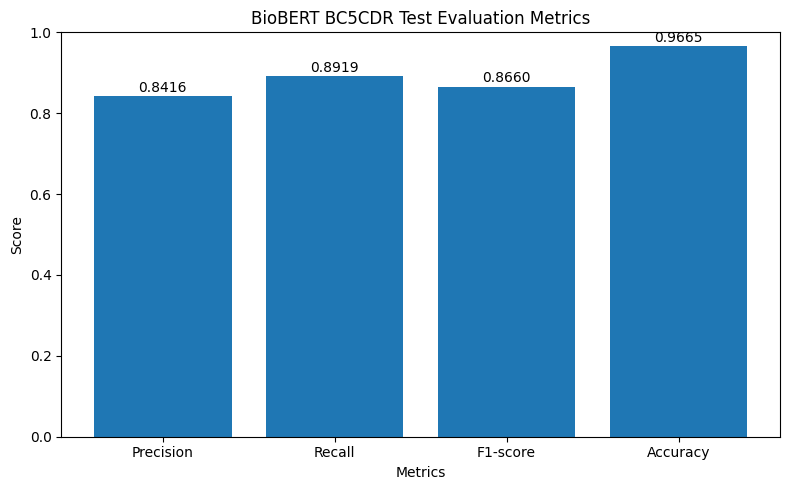

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylim(0, 1)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("BioBERT BC5CDR Test Evaluation Metrics")

for i, v in enumerate(metrics_df["Value"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")

plt.tight_layout()
plt.savefig("/content/evaluation_metrics_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

Test set

In [58]:
predictions_output = trainer.predict(tokenized_bc5cdr["test"])

pred_logits = predictions_output.predictions
true_labels = predictions_output.label_ids
pred_ids = pred_logits.argmax(axis=2)

In [59]:
true_flat = []
pred_flat = []

for pred_seq, true_seq in zip(pred_ids, true_labels):
    for p, t in zip(pred_seq, true_seq):
        if t != -100:
            true_flat.append(id2label[int(t)])
            pred_flat.append(id2label[int(p)])

print("Total evaluated tokens:", len(true_flat))

Total evaluated tokens: 172965


In [60]:
from sklearn.metrics import classification_report

print(classification_report(true_flat, pred_flat, digits=4))

              precision    recall  f1-score   support

  B-Chemical     0.9293    0.9439    0.9365      5385
   B-Disease     0.8410    0.8802    0.8602      4424
  I-Chemical     0.9399    0.9618    0.9507     15503
   I-Disease     0.8872    0.9093    0.8981     13403
           O     0.9838    0.9765    0.9801    134250

    accuracy                         0.9665    172965
   macro avg     0.9162    0.9343    0.9251    172965
weighted avg     0.9670    0.9665    0.9667    172965



In [61]:
report_text = classification_report(true_flat, pred_flat, digits=4)

with open("/content/classification_report.txt", "w") as f:
    f.write(report_text)

print(report_text)

              precision    recall  f1-score   support

  B-Chemical     0.9293    0.9439    0.9365      5385
   B-Disease     0.8410    0.8802    0.8602      4424
  I-Chemical     0.9399    0.9618    0.9507     15503
   I-Disease     0.8872    0.9093    0.8981     13403
           O     0.9838    0.9765    0.9801    134250

    accuracy                         0.9665    172965
   macro avg     0.9162    0.9343    0.9251    172965
weighted avg     0.9670    0.9665    0.9667    172965



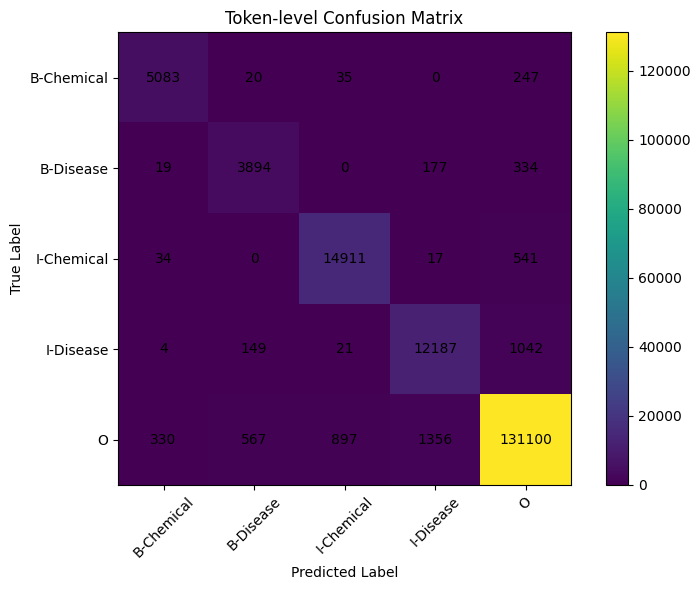

In [62]:
from sklearn.metrics import confusion_matrix
import numpy as np

labels_in_order = sorted(list(set(true_flat) | set(pred_flat)))
cm = confusion_matrix(true_flat, pred_flat, labels=labels_in_order)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Token-level Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels_in_order))
plt.xticks(tick_marks, labels_in_order, rotation=45)
plt.yticks(tick_marks, labels_in_order)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
def show_sample_prediction(dataset_split, index=0):
    sample = dataset_split[index]
    tokens = sample["tokens"]

    inputs = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    outputs = model(**inputs)
    pred_ids = outputs.logits.argmax(dim=2)[0].tolist()

    word_ids = inputs.word_ids(batch_index=0)

    final_preds = []
    prev_word_id = None

    for pred_id, word_id in zip(pred_ids, word_ids):
        if word_id is None:
            continue
        if word_id != prev_word_id:
            final_preds.append(id2label[pred_id])
        prev_word_id = word_id

    true_tags = sample["tags"]

    result_df = pd.DataFrame({
        "Token": tokens[:len(final_preds)],
        "True Label": true_tags[:len(final_preds)],
        "Predicted Label": final_preds[:len(true_tags)]
    })

    return result_df

sample_df = show_sample_prediction(bc5cdr["test"], index=0)
print(sample_df.head(30))
sample_df.to_csv("/content/sample_prediction.csv", index=False)

             Token  True Label Predicted Label
0          Torsade   B-Disease       B-Disease
1               de   I-Disease       I-Disease
2          pointes   I-Disease       I-Disease
3      ventricular   B-Disease       B-Disease
4      tachycardia   I-Disease       I-Disease
5           during           O               O
6              low           O               O
7             dose           O               O
8     intermittent           O               O
9       dobutamine  B-Chemical      B-Chemical
10       treatment           O               O
11              in           O               O
12               a           O               O
13         patient           O               O
14            with           O               O
15         dilated   B-Disease       B-Disease
16  cardiomyopathy   I-Disease       I-Disease
17             and           O               O
18      congestive   B-Disease       B-Disease
19           heart   I-Disease       I-Disease
20         fa

In [64]:
for i in range(3):
    print(f"\n===== SAMPLE {i} =====")
    display(show_sample_prediction(bc5cdr["test"], index=i).head(25))


===== SAMPLE 0 =====


,Token,True Label,Predicted Label
0,Torsade,B-Disease,B-Disease
1,de,I-Disease,I-Disease
2,pointes,I-Disease,I-Disease
3,ventricular,B-Disease,B-Disease
4,tachycardia,I-Disease,I-Disease
5,during,O,O
6,low,O,O
7,dose,O,O
8,intermittent,O,O
9,dobutamine,B-Chemical,B-Chemical



===== SAMPLE 1 =====


,Token,True Label,Predicted Label
0,The,O,O
1,authors,O,O
2,describe,O,O
3,the,O,O
4,case,O,O
5,of,O,O
6,a,O,O
7,56,O,O
8,-,O,O
9,year,O,O



===== SAMPLE 2 =====


,Token,True Label,Predicted Label
0,This,O,O
1,report,O,O
2,of,O,O
3,torsade,B-Disease,B-Disease
4,de,I-Disease,I-Disease
5,pointes,I-Disease,I-Disease
6,ventricular,B-Disease,B-Disease
7,tachycardia,I-Disease,I-Disease
8,during,O,O
9,intermittent,O,O


In [65]:
from google.colab import drive
import os
import shutil

drive.mount('/content/drive')

results_dir = "/content/drive/MyDrive/medical_ner_project/results"
os.makedirs(results_dir, exist_ok=True)

files_to_save = [
    "/content/test_metrics.csv",
    "/content/evaluation_metrics_barplot.png",
    "/content/classification_report.txt",
    "/content/confusion_matrix.png",
    "/content/sample_prediction.csv"
]

for file_path in files_to_save:
    if os.path.exists(file_path):
        shutil.copy(file_path, results_dir)

print("Saved results to:", results_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved results to: /content/drive/MyDrive/medical_ner_project/results


In [72]:
%cd /content/medagent_data/raw/synthea

/content/medagent_data/raw/synthea


In [74]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source_dir = "/content/medagent_data/raw/synthea/output/csv"
target_dir = "/content/drive/MyDrive/medical_ner_project/raw_data/synthea_csv"

os.makedirs(target_dir, exist_ok=True)

for file in os.listdir(source_dir):
    shutil.copy(os.path.join(source_dir, file), target_dir)

print("✅ Synthea saved to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Synthea saved to Drive


In [75]:
import pandas as pd
import os

base_path = "/content/medagent_data/raw/synthea/output/csv"

patients = pd.read_csv(os.path.join(base_path, "patients.csv"))
conditions = pd.read_csv(os.path.join(base_path, "conditions.csv"))
medications = pd.read_csv(os.path.join(base_path, "medications.csv"))
observations = pd.read_csv(os.path.join(base_path, "observations.csv"))
encounters = pd.read_csv(os.path.join(base_path, "encounters.csv"))

print("Loaded all Synthea CSV files")
print(patients.head(1))

Loaded all Synthea CSV files
                                     Id   BIRTHDATE DEATHDATE          SSN  \
0  b6a0779f-41f7-0291-edd3-f570686fdf66  1960-10-09       NaN  999-76-5653   

     DRIVERS    PASSPORT PREFIX       FIRST MIDDLE      LAST  ...  \
0  S99914046  X13778763X   Mrs.  Eleanor470    NaN  Block661  ...   

          CITY          STATE            COUNTY     FIPS   ZIP        LAT  \
0  North Adams  Massachusetts  Berkshire County  25003.0  1247  42.694882   

         LON HEALTHCARE_EXPENSES HEALTHCARE_COVERAGE INCOME  
0 -73.070431           757255.87           122100.39  35527  

[1 rows x 28 columns]


In [76]:
def build_patient_report(patient_id):
    patient_row = patients[patients["Id"] == patient_id].iloc[0]

    patient_conditions = conditions[conditions["PATIENT"] == patient_id]
    patient_medications = medications[medications["PATIENT"] == patient_id]
    patient_observations = observations[observations["PATIENT"] == patient_id]

    name = f"{patient_row['FIRST']} {patient_row['LAST']}"
    gender = patient_row.get("GENDER", "Unknown")
    birthdate = patient_row.get("BIRTHDATE", "Unknown")

    cond_list = patient_conditions["DESCRIPTION"].dropna().unique().tolist()
    med_list = patient_medications["DESCRIPTION"].dropna().unique().tolist()

    obs_list = []
    for _, row in patient_observations.head(10).iterrows():
        desc = str(row.get("DESCRIPTION", "")).strip()
        val = str(row.get("VALUE", "")).strip()
        units = str(row.get("UNITS", "")).strip()
        if desc:
            if val and units and units != "nan":
                obs_list.append(f"{desc}: {val} {units}")
            elif val and val != "nan":
                obs_list.append(f"{desc}: {val}")
            else:
                obs_list.append(desc)

    report = f"Patient Report\n"
    report += f"Name: {name}\n"
    report += f"Gender: {gender}\n"
    report += f"Birthdate: {birthdate}\n\n"

    report += "Conditions:\n"
    if cond_list:
        for c in cond_list[:10]:
            report += f"- {c}\n"
    else:
        report += "- None recorded\n"

    report += "\nMedications:\n"
    if med_list:
        for m in med_list[:10]:
            report += f"- {m}\n"
    else:
        report += "- None recorded\n"

    report += "\nObservations:\n"
    if obs_list:
        for o in obs_list:
            report += f"- {o}\n"
    else:
        report += "- None recorded\n"

    return report

In [77]:
sample_patient_id = patients.iloc[0]["Id"]
sample_report = build_patient_report(sample_patient_id)

print(sample_report[:2000])

Patient Report
Name: Eleanor470 Block661
Gender: F
Birthdate: 1960-10-09

Conditions:
- Only received primary school education (finding)
- Prediabetes (finding)
- Anemia (disorder)
- Body mass index 30+ - obesity (finding)
- History of tubal ligation (situation)
- Medication review due (situation)
- Full-time employment (finding)
- Stress (finding)
- Unhealthy alcohol drinking behavior (finding)
- Part-time employment (finding)

Medications:
- Acetaminophen 325 MG Oral Tablet

Observations:
- Hemoglobin A1c/Hemoglobin.total in Blood: 6.3 %
- Body Height: 167.9 cm
- Pain severity - 0-10 verbal numeric rating [Score] - Reported: 1.0 {score}
- Body Weight: 79.2 kg
- Body mass index (BMI) [Ratio]: 28.1 kg/m2
- Diastolic Blood Pressure: 88.0 mm[Hg]
- Systolic Blood Pressure: 132.0 mm[Hg]
- Heart rate: 88.0 /min
- Respiratory rate: 14.0 /min
- Glucose [Mass/volume] in Blood: 89.8 mg/dL



In [78]:
report_path = "/content/sample_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(sample_report)

print("Saved report to:", report_path)

Saved report to: /content/sample_report.txt


In [79]:
from google.colab import files
files.download(report_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Testing By uploading synthea reports

In [80]:
from google.colab import files

uploaded = files.upload()
uploaded_filename = list(uploaded.keys())[0]

with open(uploaded_filename, "r", encoding="utf-8") as f:
    uploaded_report_text = f.read()

print("Uploaded file:", uploaded_filename)
print(uploaded_report_text[:1500])

Saving sample_report.txt to sample_report.txt
Uploaded file: sample_report.txt
Patient Report
Name: Eleanor470 Block661
Gender: F
Birthdate: 1960-10-09

Conditions:
- Only received primary school education (finding)
- Prediabetes (finding)
- Anemia (disorder)
- Body mass index 30+ - obesity (finding)
- History of tubal ligation (situation)
- Medication review due (situation)
- Full-time employment (finding)
- Stress (finding)
- Unhealthy alcohol drinking behavior (finding)
- Part-time employment (finding)

Medications:
- Acetaminophen 325 MG Oral Tablet

Observations:
- Hemoglobin A1c/Hemoglobin.total in Blood: 6.3 %
- Body Height: 167.9 cm
- Pain severity - 0-10 verbal numeric rating [Score] - Reported: 1.0 {score}
- Body Weight: 79.2 kg
- Body mass index (BMI) [Ratio]: 28.1 kg/m2
- Diastolic Blood Pressure: 88.0 mm[Hg]
- Systolic Blood Pressure: 132.0 mm[Hg]
- Heart rate: 88.0 /min
- Respiratory rate: 14.0 /min
- Glucose [Mass/volume] in Blood: 89.8 mg/dL



In [82]:
import torch

def merge_wordpiece_tokens(tokens):
    merged = []
    for tok in tokens:
        if tok.startswith("##") and merged:
            merged[-1] = merged[-1] + tok[2:]
        else:
            merged.append(tok)
    return merged

def predict_entities(text, model, tokenizer, max_length=512):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    with torch.no_grad():
        outputs = model(**inputs)

    pred_ids = torch.argmax(outputs.logits, dim=2)[0].tolist()
    input_ids = inputs["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    id2label = model.config.id2label

    entities = []
    current_tokens = []
    current_type = None

    for token, pred_id in zip(tokens, pred_ids):
        label = id2label[pred_id]

        if token in tokenizer.all_special_tokens:
            continue

        if label.startswith("B-"):
            if current_tokens:
                entities.append({
                    "entity_text": " ".join(merge_wordpiece_tokens(current_tokens)),
                    "entity_type": current_type
                })
            current_tokens = [token]
            current_type = label[2:]

        elif label.startswith("I-") and current_type == label[2:]:
            current_tokens.append(token)

        else:
            if current_tokens:
                entities.append({
                    "entity_text": " ".join(merge_wordpiece_tokens(current_tokens)),
                    "entity_type": current_type
                })
                current_tokens = []
                current_type = None

    if current_tokens:
        entities.append({
            "entity_text": " ".join(merge_wordpiece_tokens(current_tokens)),
            "entity_type": current_type
        })

    return entities

In [83]:
entities = predict_entities(uploaded_report_text, model, tokenizer)

print("Extracted Entities:")
for e in entities:
    print(e)

Extracted Entities:
{'entity_text': 'Prediabetes', 'entity_type': 'Disease'}
{'entity_text': 'Anemia', 'entity_type': 'Disease'}
{'entity_text': 'obesity', 'entity_type': 'Disease'}
{'entity_text': 'alcohol', 'entity_type': 'Chemical'}
{'entity_text': 'Acetaminophen', 'entity_type': 'Chemical'}
{'entity_text': 'Pain', 'entity_type': 'Disease'}
{'entity_text': 'Glucose', 'entity_type': 'Chemical'}


In [84]:
import os

report_dir = "/content/synthea_reports"
os.makedirs(report_dir, exist_ok=True)

for i in range(min(5, len(patients))):
    patient_id = patients.iloc[i]["Id"]
    report_text = build_patient_report(patient_id)

    file_path = os.path.join(report_dir, f"patient_report_{i+1}.txt")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(report_text)

print("Created files:", os.listdir(report_dir))

Created files: ['patient_report_5.txt', 'patient_report_2.txt', 'patient_report_4.txt', 'patient_report_3.txt', 'patient_report_1.txt']


In [85]:
import shutil
from google.colab import files

zip_path = shutil.make_archive("/content/synthea_reports", "zip", "/content/synthea_reports")
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
df = pd.DataFrame(entities)

diseases = df[df["entity_type"] == "Disease"]["entity_text"].unique()
chemicals = df[df["entity_type"] == "Chemical"]["entity_text"].unique()

print("Diseases:", diseases)
print("Chemicals:", chemicals)

Diseases: ['Prediabetes' 'Anemia' 'obesity' 'Pain']
Chemicals: ['alcohol' 'Acetaminophen' 'Glucose']


In [90]:
explanations = {
    "Prediabetes": "High blood sugar levels, not yet diabetes",
    "Anemia": "Low red blood cell count",
    "Acetaminophen": "Pain reliever medication"
}

for e in entities:
    if e["entity_text"] in explanations:
        e["explanation"] = explanations[e["entity_text"]]
    else:
        e["explanation"] = "No explanation available"

pd.DataFrame(entities)

,entity_text,entity_type,explanation
0,Prediabetes,Disease,"High blood sugar levels, not yet diabetes"
1,Anemia,Disease,Low red blood cell count
2,obesity,Disease,No explanation available
3,alcohol,Chemical,No explanation available
4,Acetaminophen,Chemical,Pain reliever medication
5,Pain,Disease,No explanation available
6,Glucose,Chemical,No explanation available


Medquad integration

In [94]:
from datasets import load_from_disk

medquad_ds = load_from_disk("/content/drive/MyDrive/medical_ner_project/medquad_ds")
print(medquad_ds)
print(medquad_ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer'],
        num_rows: 47441
    })
})
{'document_id': '0000559', 'document_source': 'GHR', 'document_url': 'https://ghr.nlm.nih.gov/condition/keratoderma-with-woolly-hair', 'category': None, 'umls_cui': 'C0343073', 'umls_semantic_types': 'T047', 'umls_semantic_group': 'Disorders', 'synonyms': 'KWWH', 'question_id': '0000559-1', 'question_focus': 'keratoderma with woolly hair', 'question_type': 'information', 'question': 'What is (are) keratoderma with woolly hair ?', 'answer': 'Keratoderma with woolly hair is a group of related conditions that affect the skin and hair and in many cases increase the risk of potentially life-threatening heart problems. People with these conditions have hair that is unusually coarse, dry, fine, and tightl

In [95]:
print(medquad_ds["train"].column_names)

['document_id', 'document_source', 'document_url', 'category', 'umls_cui', 'umls_semantic_types', 'umls_semantic_group', 'synonyms', 'question_id', 'question_focus', 'question_type', 'question', 'answer']


In [96]:
import pandas as pd
import re

def clean_text(text):
    return str(text).strip().lower()

def retrieve_medquad_explanation(entity_text, medquad_split, max_results=1):
    entity = clean_text(entity_text)
    matches = []

    for item in medquad_split:
        question = clean_text(item.get("question", ""))
        answer = str(item.get("answer", "")).strip()

        if not question or not answer:
            continue

        # direct containment match
        if entity in question:
            matches.append({
                "matched_question": item.get("question", ""),
                "matched_answer": answer
            })

    if len(matches) == 0:
        return {
            "matched_question": "No matching MedQuAD question found",
            "matched_answer": "No explanation available from MedQuAD."
        }

    return matches[0]

In [97]:
def enrich_entities_with_medquad(entities, medquad_split):
    enriched = []

    for ent in entities:
        medquad_match = retrieve_medquad_explanation(ent["entity_text"], medquad_split)

        enriched.append({
            "entity_text": ent["entity_text"],
            "entity_type": ent["entity_type"],
            "matched_question": medquad_match["matched_question"],
            "medquad_answer": medquad_match["matched_answer"]
        })

    return enriched

In [98]:
def build_grouped_summary(df):
    if df.empty:
        return "No entities found."

    diseases = df[df["entity_type"] == "Disease"]["entity_text"].drop_duplicates().tolist()
    chemicals = df[df["entity_type"] == "Chemical"]["entity_text"].drop_duplicates().tolist()

    summary = []
    summary.append(f"Total entities found: {len(df)}")
    summary.append(f"Diseases found: {len(diseases)}")
    summary.append(f"Chemicals found: {len(chemicals)}")

    if diseases:
        summary.append("Diseases: " + ", ".join(diseases))
    if chemicals:
        summary.append("Chemicals: " + ", ".join(chemicals))

    return "\n".join(summary)

Gradio Interface

In [92]:
!pip install -q gradio pandas

In [99]:
import gradio as gr
import pandas as pd

def analyze_with_medquad(file, text_input):
    # Read uploaded file or textbox input
    if file is not None:
        file_path = file if isinstance(file, str) else file.name
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()
    elif text_input and text_input.strip():
        text = text_input.strip()
    else:
        empty_df = pd.DataFrame(columns=["entity_text", "entity_type", "matched_question", "medquad_answer"])
        grouped_df = pd.DataFrame(columns=["Category", "Entities"])
        return "No input provided.", empty_df, grouped_df, "No entities found."

    # Run NER
    entities = predict_entities(text, model, tokenizer)

    if len(entities) == 0:
        detailed_df = pd.DataFrame(columns=["entity_text", "entity_type", "matched_question", "medquad_answer"])
        grouped_df = pd.DataFrame(columns=["Category", "Entities"])
        summary = "No disease or chemical entities were found."
    else:
        enriched_entities = enrich_entities_with_medquad(entities, medquad_ds["train"])
        detailed_df = pd.DataFrame(enriched_entities).drop_duplicates().reset_index(drop=True)

        diseases = detailed_df[detailed_df["entity_type"] == "Disease"]["entity_text"].drop_duplicates().tolist()
        chemicals = detailed_df[detailed_df["entity_type"] == "Chemical"]["entity_text"].drop_duplicates().tolist()

        grouped_df = pd.DataFrame([
            {
                "Category": "Diseases",
                "Entities": ", ".join(diseases) if diseases else "None"
            },
            {
                "Category": "Chemicals",
                "Entities": ", ".join(chemicals) if chemicals else "None"
            }
        ])

        summary = build_grouped_summary(detailed_df)

    return text, detailed_df, grouped_df, summary

demo = gr.Interface(
    fn=analyze_with_medquad,
    inputs=[
        gr.File(label="Upload Patient Report (.txt)", file_types=[".txt"]),
        gr.Textbox(
            label="Or Paste Medical Text Here",
            lines=12,
            placeholder="Paste a patient report or medical paragraph here..."
        )
    ],
    outputs=[
        gr.Textbox(label="Input Text", lines=12),
        gr.Dataframe(label="Extracted Entities + MedQuAD Explanations"),
        gr.Dataframe(label="Grouped Output"),
        gr.Textbox(label="Summary", lines=8)
    ],
    title="Biomedical NER + MedQuAD Explanation Assistant",
    description="Upload a patient report or paste medical text. The system extracts disease and chemical entities using BioBERT and retrieves related explanations from MedQuAD."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1034b0d5c11068462.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
